# Priprema podataka za klasifikaciju proizvoda
Ova sveska učitava, analizira, čisti i priprema skup proizvoda za model automatske klasifikacije kategorija. Obrada koristi relativne putanje i sprečava curenje podataka između trening i test skupa.

In [10]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
DATA_PATH = Path("IMLP6_TASK_03-products.csv")
OUTPUT_DIR = Path("data/processed")

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 2)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

if not DATA_PATH.exists():
    raise FileNotFoundError(f"CSV fajl nije pronađen: {DATA_PATH.resolve()}")

data_raw = pd.read_csv(DATA_PATH)
raw_shape = data_raw.shape
print(f"Učitano je {raw_shape[0]:,} redova i {raw_shape[1]} kolona.")

Učitano je 35,311 redova i 8 kolona.


## 1. Početna analiza kvaliteta
Proveravamo nazive i tipove kolona, prazne vrednosti, kardinalnost, duplikate i raspodelu ciljne kategorije pre bilo kakve izmene podataka.

Potpuno duplirani redovi: 0


,dtype,missing,missing_pct,unique
product_id,int64,0,0.00,35311
product_title,str,172,0.49,30861
merchant_id,int64,0,0.00,306
category_label,str,44,0.12,14
product_code,str,95,0.27,35217
number_of_views,float64,14,0.04,5000
merchant_rating,float64,170,0.48,42
listing_date,str,59,0.17,1097


,product_id,product_title,merchant_id,category_label,product_code,number_of_views,merchant_rating,listing_date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


,count
category,
Fridge Freezers,5495
Washing Machines,4036
Mobile Phones,4020
CPUs,3771
TVs,3564
Fridges,3457
Dishwashers,3418
Digital Cameras,2696
Microwaves,2338


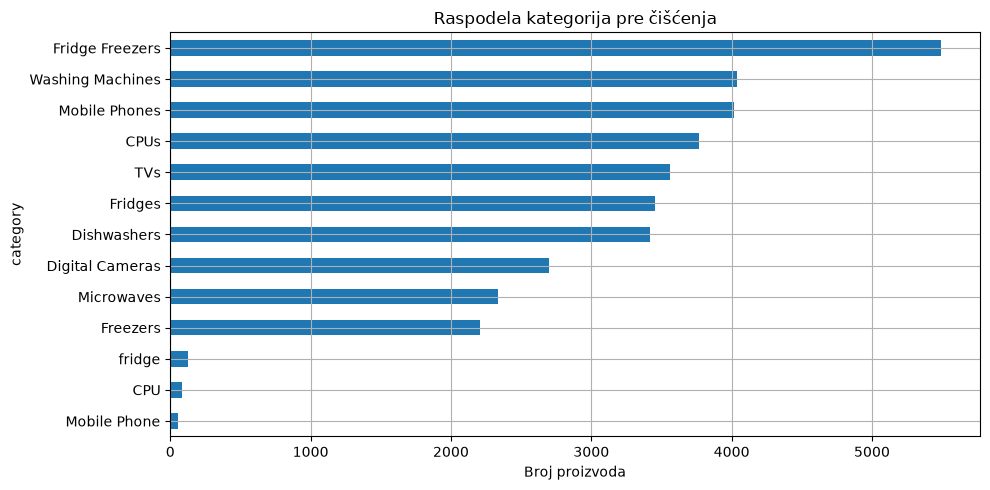

In [11]:
def normalize_column_name(column_name):
    normalized = re.sub(r"[^0-9a-zA-Z]+", "_", column_name.strip().lower())
    return normalized.strip("_")

data_raw.columns = [normalize_column_name(column) for column in data_raw.columns]

quality_report = pd.DataFrame(
    {
        "dtype": data_raw.dtypes.astype(str),
        "missing": data_raw.isna().sum(),
        "missing_pct": data_raw.isna().mean().mul(100).round(2),
        "unique": data_raw.nunique(dropna=False),
    }
)

print(f"Potpuno duplirani redovi: {data_raw.duplicated().sum():,}")
display(quality_report)
display(data_raw.head())

target_before_cleaning = (
    data_raw["category_label"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("category")
    .to_frame("count")
)
display(target_before_cleaning)

target_before_cleaning.drop(index=pd.NA, errors="ignore").sort_values("count").plot.barh(
    legend=False, title="Raspodela kategorija pre čišćenja"
 )
plt.xlabel("Broj proizvoda")
plt.tight_layout()
plt.show()

## 2. Čišćenje i standardizacija
Uklanjamo zapise bez naslova ili cilja, objedinjujemo neujednačene oznake kategorija, normalizujemo tekst i datume, rešavamo nedostajuće vrednosti i uklanjamo konfliktne ili ponovljene naslove. Identifikatori ostaju radi praćenja, ali se ne koriste kao karakteristike modela.

In [12]:
data = data_raw.copy()

text_columns = ["product_title", "category_label", "product_code"]
for column in text_columns:
    data[column] = (
        data[column]
        .astype("string")
        .str.normalize("NFKC")
        .str.strip()
        .replace("", pd.NA)
    )

required_missing_mask = data[["product_title", "category_label"]].isna().any(axis=1)
dropped_required = int(required_missing_mask.sum())
data = data.loc[~required_missing_mask].copy()

category_aliases = {
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones",
    "fridge": "Fridges",
}
data["category_label"] = data["category_label"].replace(category_aliases)

data["product_title_clean"] = (
    data["product_title"]
    .str.lower()
    .str.replace(r"[\W_]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
 )
data = data.loc[data["product_title_clean"].ne("")].copy()

data["number_of_views_missing"] = data["number_of_views"].isna().astype("int8")
data["merchant_rating_missing"] = data["merchant_rating"].isna().astype("int8")
data["number_of_views"] = pd.to_numeric(data["number_of_views"], errors="coerce").clip(lower=0)
data["merchant_rating"] = pd.to_numeric(data["merchant_rating"], errors="coerce")
data.loc[~data["merchant_rating"].between(1, 5), "merchant_rating"] = np.nan
data["number_of_views"] = data["number_of_views"].fillna(data["number_of_views"].median())
data["merchant_rating"] = data["merchant_rating"].fillna(data["merchant_rating"].median())

data["listing_date"] = pd.to_datetime(
    data["listing_date"], format="%m/%d/%Y", errors="coerce"
 )
data["listing_date_missing"] = data["listing_date"].isna().astype("int8")
median_listing_date = data["listing_date"].dropna().median()
data["listing_date"] = data["listing_date"].fillna(median_listing_date)
data["listing_year"] = data["listing_date"].dt.year
data["listing_month"] = data["listing_date"].dt.month
data["listing_dayofweek"] = data["listing_date"].dt.dayofweek
data["product_code"] = data["product_code"].fillna("unknown")

labels_per_title = data.groupby("product_title_clean")["category_label"].nunique()
ambiguous_titles = labels_per_title[labels_per_title.gt(1)].index
ambiguous_mask = data["product_title_clean"].isin(ambiguous_titles)
removed_ambiguous = int(ambiguous_mask.sum())
data = data.loc[~ambiguous_mask].copy()

data = data.sort_values("number_of_views", ascending=False)
removed_repeated_titles = int(data.duplicated("product_title_clean").sum())
data_clean = (
    data.drop_duplicates("product_title_clean", keep="first")
    .sort_values("product_id")
    .reset_index(drop=True)
 )

cleaning_summary = pd.Series(
    {
        "raw_rows": raw_shape[0],
        "dropped_missing_title_or_target": dropped_required,
        "removed_ambiguous_title_rows": removed_ambiguous,
        "removed_repeated_title_rows": removed_repeated_titles,
        "clean_rows": len(data_clean),
        "clean_categories": data_clean["category_label"].nunique(),
        "remaining_missing_values": int(data_clean.isna().sum().sum()),
    },
    name="value",
 )
display(cleaning_summary.to_frame())
display(data_clean["category_label"].value_counts().rename_axis("category").to_frame("count"))

,value
raw_rows,35311
dropped_missing_title_or_target,215
removed_ambiguous_title_rows,4
removed_repeated_title_rows,4276
clean_rows,30816
clean_categories,10
remaining_missing_values,0


,count
category,
Fridge Freezers,4806
Mobile Phones,3662
Washing Machines,3399
TVs,3275
Fridges,3188
CPUs,3043
Dishwashers,3041
Digital Cameras,2405
Microwaves,2094


## 3. Nalazi i predlozi za inženjering karakteristika

### Šta već koristimo

- **Word TF-IDF (unigrami i bigrami)** iz očišćenog naslova: osnovni i najvažniji signal za kategoriju.
- **`merchant_id` kao One-Hot feature**: trgovci često imaju specijalizovan asortiman.
- **Numeričke i vremenske karakteristike**: broj pregleda, ocena trgovca, godina, mesec, dan u nedelji i indikatori nedostajućih vrednosti.

### Nalazi iz skupa

- Naslov ima medijanu od **8 reči i 51 karakter**, pa sadrži dovoljno teksta za n-grame.
- Oko **97%** naslova sadrži broj, **83%** alfanumeričku oznaku modela, **32%** jedinicu kapaciteta, a **17%** dimenziju. Ovi obrasci mogu razlikovati telefone, televizore, belu tehniku i kamere.
- Skup ima **301 trgovca**. Medijana udela najčešće kategorije po trgovcu je oko **83%**, a **137 trgovaca** se pojavljuje samo u jednoj kategoriji. To je potencijalno jak signal, ali može loše raditi za novog trgovca.
- Prosečan broj pregleda po kategorijama vrlo malo varira (koeficijent varijacije oko **1,4%**), a prosečna ocena trgovca je približno između **2,97 i 3,06**. Ove kolone verovatno imaju malu samostalnu vrednost.
- Prefiks šifre proizvoda je veoma rasut i slab signal, zato ceo `product_code` i njegov prefiks za sada ne treba koristiti.

### Prioritetni eksperimenti

1. **Character TF-IDF (`char_wb`, 3-5 znakova)**  
   Hvata modele, skraćenice, pravopisne varijacije i oblike kao `64gb`, `iphone-12` ili `55inch`. Testirati samostalno i zajedno sa word TF-IDF.

2. **Ekstrakcija tehničkih specifikacija iz naslova**  
   Kreirati indikatore i numeričke vrednosti za `GB/TB`, `inch/cm`, `kg`, `l`, `MP`, `mAh`, `Hz` i `W`. Svrha je da model dobije eksplicitne signale kao što su kapacitet, dijagonala i snaga.

3. **Strukturne karakteristike naslova**  
   Broj reči, broj karaktera, broj cifara, odnos cifara i slova, prisustvo modelskog koda i broj jedinica mere. Mogu pomoći kada su pojedinačne reči retke.

4. **Karakteristike trgovca bez curenja cilja**  
   Pored One-Hot kodiranja testirati frekvenciju trgovca i out-of-fold target encoding sa zaglađivanjem. Target encoding se mora učiti samo na trening foldovima. Posebno meriti rezultat na trgovcima koji nisu viđeni tokom treninga.

5. **Transformacije pregleda i datuma**  
   Testirati `log1p(number_of_views)`, starost oglasa u danima i ciklično kodiranje meseca (`sin/cos`). Zadržati ih samo ako poprave macro F1; početna analiza ukazuje da će doprinos verovatno biti mali.

### Pravilo odlučivanja

Svaki dodatak testirati kao ablation eksperiment u odnosu na isti baseline i istu podelu podataka. Beležiti **macro F1**, accuracy, broj karakteristika, vreme treniranja i rezultat po kategoriji. Feature zadržati samo ako stabilno poboljšava validaciju bez curenja podataka. Pored stratifikovane podele koristiti i proveru sa grupisanjem po trgovcu ili vremensku podelu, jer nasumična podela može preceniti učinak `merchant_id` karakteristike.

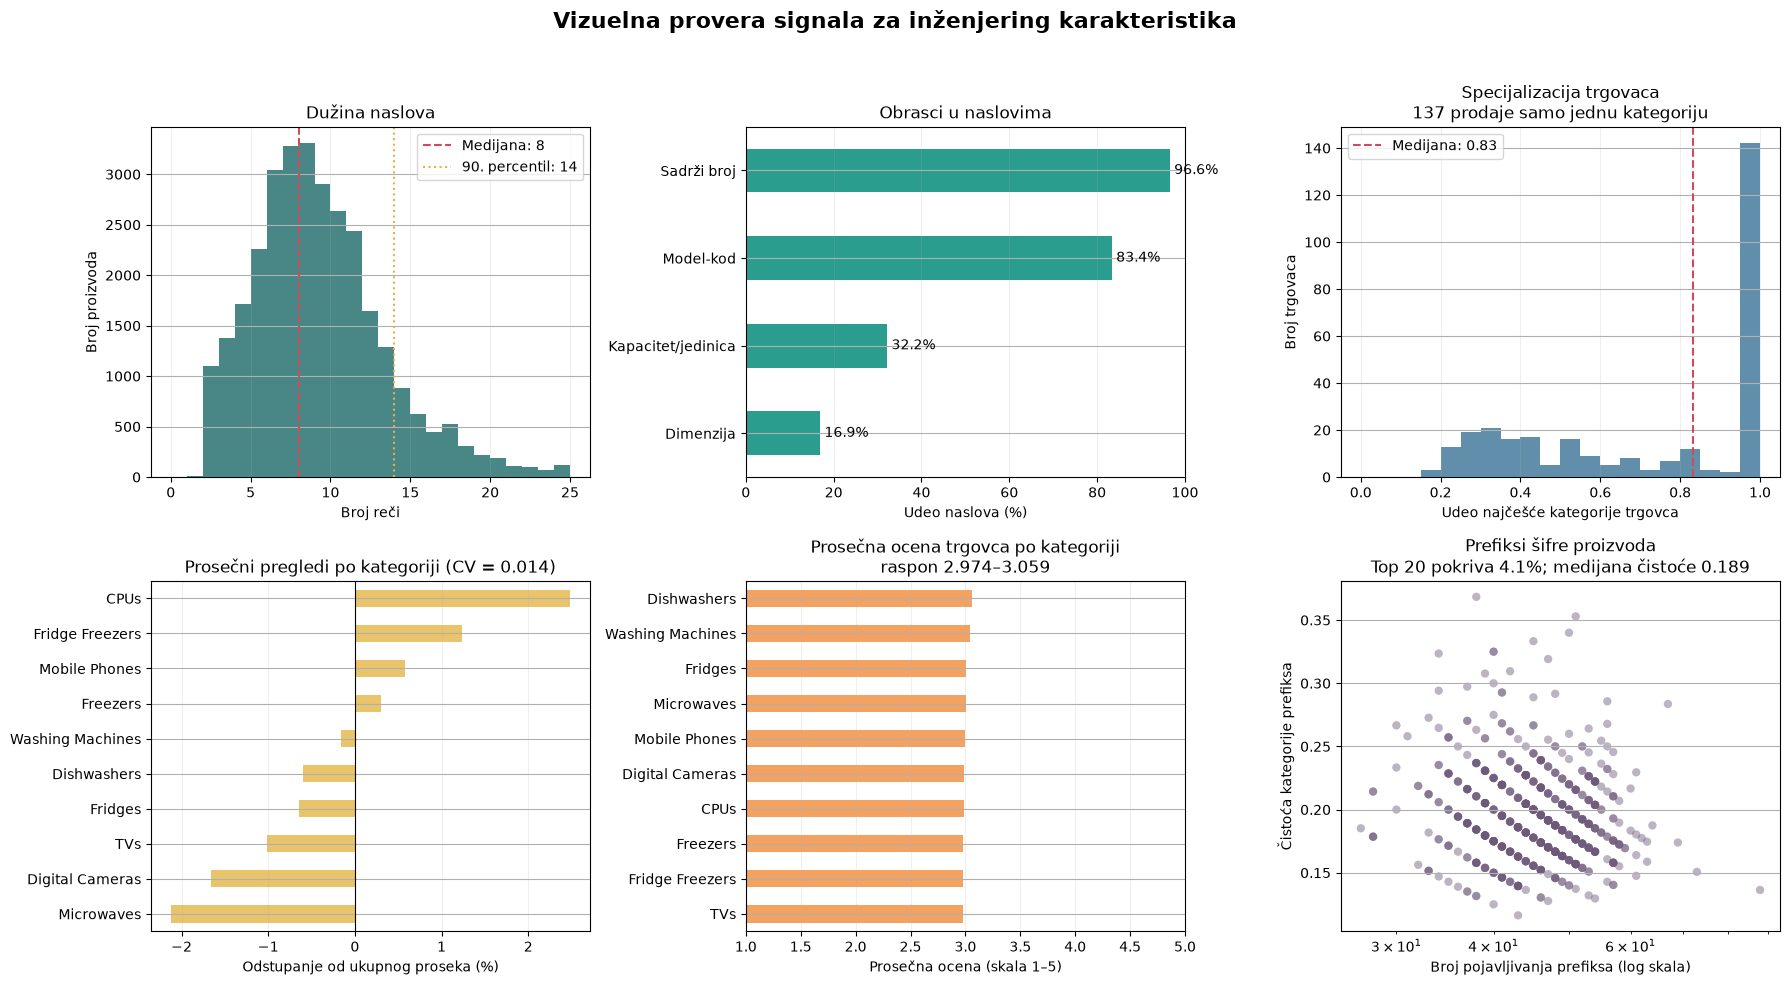

,Pokazatelj,Vrednost
0,Medijana broja reči,8
1,90. percentil broja reči,14
2,Medijana broja karaktera,51
3,Broj trgovaca,301
4,Medijana čistoće trgovca,0.833
5,Trgovci sa jednom kategorijom,137
6,CV prosečnih pregleda po kategoriji,0.014
7,Raspon prosečnih ocena po kategoriji,2.974–3.059
8,Broj prefiksa šifre,677
9,Pokrivenost top 20 prefiksa,4.1%


In [15]:
# Vizuelna potvrda nalaza o potencijalnim karakteristikama
titles = data_clean["product_title_clean"].fillna("")
word_counts = titles.str.split().str.len()
character_counts = titles.str.len()

title_patterns = pd.Series(
    {
        "Sadrži broj": titles.str.contains(r"\d", regex=True).mean(),
        "Model-kod": titles.str.contains(
            r"\b(?=\w*[a-z])(?=\w*\d)[a-z0-9-]{4,}\b",
            regex=True,
        ).mean(),
        "Kapacitet/jedinica": titles.str.contains(
            r"\b\d+\s*(?:gb|tb|l|kg|inch|inches|cm|mp|mah|hz|w)\b",
            regex=True,
        ).mean(),
        "Dimenzija": titles.str.contains(
            r"\b\d+(?:\.\d+)?\s*(?:inch|inches|cm|mm)\b",
            regex=True,
        ).mean(),
    }
).mul(100).sort_values()

merchant_category_counts = pd.crosstab(
    data_clean["merchant_id"], data_clean["category_label"]
)
merchant_purity = (
    merchant_category_counts.max(axis=1) / merchant_category_counts.sum(axis=1)
)
single_category_merchants = int((merchant_category_counts.gt(0).sum(axis=1) == 1).sum())

category_means = data_clean.groupby("category_label")[[
    "number_of_views", "merchant_rating"
 ]].mean()
views_cv = category_means["number_of_views"].std() / category_means["number_of_views"].mean()
views_deviation = (
    category_means["number_of_views"] / data_clean["number_of_views"].mean() - 1
).mul(100).sort_values()

product_prefix = (
    data_clean["product_code"]
    .astype(str)
    .str.extract(r"^([A-Za-z]+)", expand=False)
    .fillna("unknown")
)
prefix_category_counts = pd.crosstab(product_prefix, data_clean["category_label"])
prefix_frequency = prefix_category_counts.sum(axis=1)
prefix_purity = prefix_category_counts.max(axis=1) / prefix_frequency
top20_prefix_coverage = prefix_frequency.nlargest(20).sum() / len(data_clean)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Vizuelna provera signala za inženjering karakteristika", fontsize=16, fontweight="bold")

axes[0, 0].hist(word_counts, bins=range(0, int(word_counts.quantile(0.99)) + 2), color="#287271", alpha=0.85)
axes[0, 0].axvline(word_counts.median(), color="#d1495b", linestyle="--", label=f"Medijana: {word_counts.median():.0f}")
axes[0, 0].axvline(word_counts.quantile(0.9), color="#edae49", linestyle=":", label=f"90. percentil: {word_counts.quantile(0.9):.0f}")
axes[0, 0].set(title="Dužina naslova", xlabel="Broj reči", ylabel="Broj proizvoda")
axes[0, 0].legend()

title_patterns.plot.barh(ax=axes[0, 1], color="#2a9d8f")
axes[0, 1].set(title="Obrasci u naslovima", xlabel="Udeo naslova (%)", ylabel="")
axes[0, 1].set_xlim(0, 100)
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt="%.1f%%", padding=3)

axes[0, 2].hist(merchant_purity, bins=np.linspace(0, 1, 21), color="#457b9d", alpha=0.85)
axes[0, 2].axvline(merchant_purity.median(), color="#d1495b", linestyle="--", label=f"Medijana: {merchant_purity.median():.2f}")
axes[0, 2].set(
    title=f"Specijalizacija trgovaca\n{single_category_merchants} prodaje samo jednu kategoriju",
    xlabel="Udeo najčešće kategorije trgovca",
    ylabel="Broj trgovaca",
)
axes[0, 2].legend()

views_deviation.plot.barh(ax=axes[1, 0], color="#e9c46a")
axes[1, 0].axvline(0, color="black", linewidth=0.8)
axes[1, 0].set(
    title=f"Prosečni pregledi po kategoriji (CV = {views_cv:.3f})",
    xlabel="Odstupanje od ukupnog proseka (%)",
    ylabel="",
)

category_means["merchant_rating"].sort_values().plot.barh(ax=axes[1, 1], color="#f4a261")
axes[1, 1].set(
    title=("Prosečna ocena trgovca po kategoriji\n"
           f"raspon {category_means['merchant_rating'].min():.3f}–{category_means['merchant_rating'].max():.3f}"),
    xlabel="Prosečna ocena (skala 1–5)",
    ylabel="",
    xlim=(1, 5),
)

axes[1, 2].scatter(prefix_frequency, prefix_purity, alpha=0.45, color="#6d597a", edgecolors="none")
axes[1, 2].set_xscale("log")
axes[1, 2].set(
    title=("Prefiksi šifre proizvoda\n"
           f"Top 20 pokriva {top20_prefix_coverage:.1%}; medijana čistoće {prefix_purity.median():.3f}"),
    xlabel="Broj pojavljivanja prefiksa (log skala)",
    ylabel="Čistoća kategorije prefiksa",
)

for axis in axes.flat:
    axis.grid(axis="x", alpha=0.2)

plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

visual_summary = pd.DataFrame(
    {
        "Pokazatelj": [
            "Medijana broja reči",
            "90. percentil broja reči",
            "Medijana broja karaktera",
            "Broj trgovaca",
            "Medijana čistoće trgovca",
            "Trgovci sa jednom kategorijom",
            "CV prosečnih pregleda po kategoriji",
            "Raspon prosečnih ocena po kategoriji",
            "Broj prefiksa šifre",
            "Pokrivenost top 20 prefiksa",
            "Medijana čistoće prefiksa",
        ],
        "Vrednost": [
            f"{word_counts.median():.0f}",
            f"{word_counts.quantile(0.9):.0f}",
            f"{character_counts.median():.0f}",
            f"{len(merchant_purity)}",
            f"{merchant_purity.median():.3f}",
            f"{single_category_merchants}",
            f"{views_cv:.3f}",
            f"{category_means['merchant_rating'].min():.3f}–{category_means['merchant_rating'].max():.3f}",
            f"{len(prefix_frequency)}",
            f"{top20_prefix_coverage:.1%}",
            f"{prefix_purity.median():.3f}",
        ],
    }
)
display(visual_summary)

## 4. Priprema za modeliranje
Skup delimo stratifikovano na trening i test podatke. Naslov se pretvara u TF-IDF karakteristike, numeričke kolone se imputiraju i standardizuju, a `merchant_id` se kodira bez korišćenja skoro jedinstvenih identifikatora `product_id` i `product_code`. Duplikati normalizovanih naslova uklonjeni su pre podele, pa isti proizvod ne može završiti u oba skupa.

In [13]:
feature_columns = [
    "product_title_clean",
    "merchant_id",
    "number_of_views",
    "merchant_rating",
    "listing_year",
    "listing_month",
    "listing_dayofweek",
    "number_of_views_missing",
    "merchant_rating_missing",
    "listing_date_missing",
]
target_column = "category_label"

model_data = data_clean[feature_columns + [target_column]].copy()
model_data["merchant_id"] = model_data["merchant_id"].astype("string")

X = model_data[feature_columns]
y = model_data[target_column]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
 )

numeric_columns = [
    "number_of_views",
    "merchant_rating",
    "listing_year",
    "listing_month",
    "listing_dayofweek",
    "number_of_views_missing",
    "merchant_rating_missing",
    "listing_date_missing",
]
categorical_columns = ["merchant_id"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
 )

preprocessor = ColumnTransformer(
    transformers=[
        (
            "title_tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                max_features=30_000,
                sublinear_tf=True,
                dtype=np.float32,
            ),
            "product_title_clean",
        ),
        ("numeric", numeric_pipeline, numeric_columns),
        (
            "merchant",
            OneHotEncoder(handle_unknown="ignore", dtype=np.float32),
            categorical_columns,
        ),
    ],
    remainder="drop",
 )

X_train_prepared = preprocessor.fit_transform(X_train, y_train)
X_test_prepared = preprocessor.transform(X_test)

assert data_clean["product_title_clean"].is_unique
assert data_clean.isna().sum().sum() == 0
assert y_train.nunique() == y_test.nunique() == data_clean[target_column].nunique()
assert set(X_train["product_title_clean"]).isdisjoint(X_test["product_title_clean"])
assert X_train_prepared.shape[0] == len(X_train)
assert X_test_prepared.shape[0] == len(X_test)
assert X_train_prepared.shape[1] == X_test_prepared.shape[1]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
data_clean.to_csv(OUTPUT_DIR / "products_clean.csv", index=False)
X_train.assign(category_label=y_train).to_csv(OUTPUT_DIR / "train.csv", index=False)
X_test.assign(category_label=y_test).to_csv(OUTPUT_DIR / "test.csv", index=False)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "features_after_preprocessing": [
            X_train_prepared.shape[1],
            X_test_prepared.shape[1],
        ],
        "categories": [y_train.nunique(), y_test.nunique()],
    },
    index=["train", "test"],
 )
display(split_summary)

distribution_check = pd.concat(
    [
        y.value_counts(normalize=True).rename("all"),
        y_train.value_counts(normalize=True).rename("train"),
        y_test.value_counts(normalize=True).rename("test"),
    ],
    axis=1,
 ).mul(100).round(2)
display(distribution_check)

print("Validacija je uspešna: podaci su očišćeni i spremni za modeliranje.")
print(f"Izlazni fajlovi su sačuvani u: {OUTPUT_DIR.resolve()}")

,rows,features_after_preprocessing,categories
train,24652,25761,10
test,6164,25761,10


,all,train,test
category_label,,,
Fridge Freezers,15.6,15.6,15.59
Mobile Phones,11.88,11.89,11.88
Washing Machines,11.03,11.03,11.03
TVs,10.63,10.63,10.63
Fridges,10.35,10.34,10.35
CPUs,9.87,9.87,9.88
Dishwashers,9.87,9.87,9.86
Digital Cameras,7.8,7.8,7.8
Microwaves,6.8,6.79,6.8


Validacija je uspešna: podaci su očišćeni i spremni za modeliranje.
Izlazni fajlovi su sačuvani u: C:\Users\s.framework\.vscode\python-project\Nemanja_Sovic_Zavrsni_Projekat\screenshotovi\product-category-prediction\data\processed
